In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
input_path = "dataset/mnist_28x28.npz"
data = np.load(input_path, allow_pickle=True)

size = [8, 8]
output_path = f"dataset/mnist_{size[0]}x{size[1]}.npz"

In [18]:
data["classes"]

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U1')

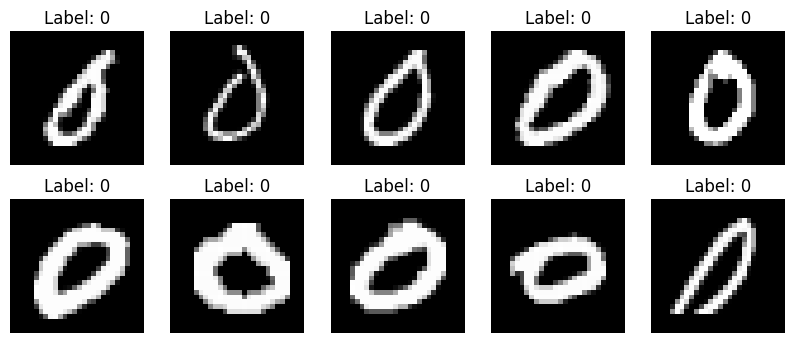

In [19]:
# Afficher quelques images originales
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    axes[i//5, i%5].imshow(data["X"][i], cmap='gray')
    axes[i//5, i%5].set_title(f"Label: {data["y"][i]}")
    axes[i//5, i%5].axis('off')

In [20]:
import numpy as np
from skimage.transform import resize
from skimage.color import rgb2gray

def redimensionner_npz(input_path, output_path, new_size=(8, 8)):
    """
    Redimentionne et met en gris (l'entrée est en couleur) les images contenues dans un fichier .npz.
    """

    data = np.load(input_path, allow_pickle=True)
    
    new_data = {}
    
    for key in data.files:
        array = data[key]
        
        if array.ndim >= 3 and array.shape[1] == 28 and array.shape[2] == 28:
            n_images = array.shape[0]
            new_shape = (n_images, new_size[0], new_size[1])
            
            resized_array = np.zeros(new_shape)
            for i in range(n_images):
                img_gray = array[i]
                if img_gray.shape[-1] == 3:
                    img_gray = rgb2gray(img_gray)
                resized_array[i] = resize(img_gray, new_size, anti_aliasing=True)
                
            new_data[key] = resized_array
            
        elif key == 'size':
            print(f"Mise à jour de la taille dans les métadonnées.")
            new_data[key] = np.array(new_size)
        elif key == 'class_names' or key == 'classes':
            print(f"Mise à jour des noms/classes des catégories.")
            new_data['classes'] = array
        else:
            print(f"Copie de '{key}' sans modification.")
            new_data[key] = array

    # 3. Sauvegarder dans un nouveau fichier .npz
    # **new_data déballe le dictionnaire en arguments nommés
    np.savez(output_path, **new_data)
    print(f"Terminé ! Fichier sauvegardé sous : {output_path}")


redimensionner_npz(input_path, output_path, new_size=size)


Copie de 'y' sans modification.
Mise à jour des noms/classes des catégories.
Mise à jour de la taille dans les métadonnées.
Terminé ! Fichier sauvegardé sous : dataset/mnist_8x8.npz


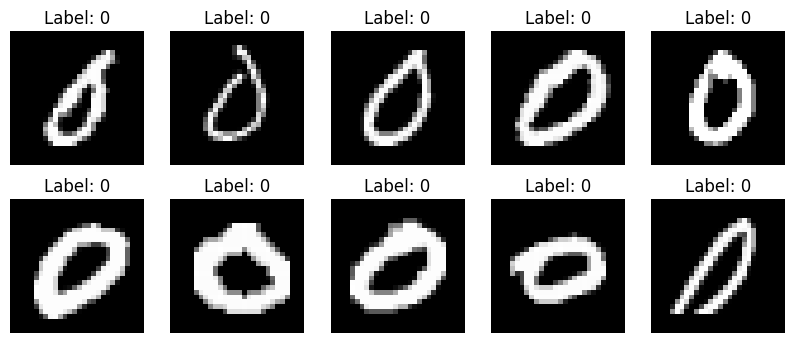

In [11]:
# Afficher quelques images redimensionnées
data_resized = np.load(output_path, allow_pickle=True)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    axes[i//5, i%5].imshow(data_resized["X"][i], cmap='gray')
    axes[i//5, i%5].set_title(f"Label: {data_resized['y'][i]}")
    axes[i//5, i%5].axis('off')

In [ ]:
import torch
from torchvision import datasets
import numpy as np

def create_balanced_mnist_10_classes(output_file="mnist_balanced_10k.npz", 
                                     samples_per_class=1000):
    
    print(f"Préparation : {samples_per_class} images pour CHAQUE chiffre (0 à 9)...")

    # 1. Chargement du dataset complet
    dataset = datasets.MNIST(root='./data', train=True, download=True)
    X_all = dataset.data.numpy()
    y_all = dataset.targets.numpy()

    X_list = []
    y_list = []

    # 2. Boucle pour récupérer 1000 images de chaque chiffre
    for i in range(10):
        # On ne prend que les images du chiffre 'i'
        mask = (y_all == i)
        X_class = X_all[mask]
        y_class = y_all[mask]
        
        # On mélange pour ne pas prendre toujours les mêmes (optionnel mais recommandé)
        indices = np.arange(len(X_class))
        np.random.shuffle(indices)
        
        # On sélectionne les N premiers
        # Note: MNIST a ~6000 images par classe, donc 1000 c'est large.
        X_selected = X_class[indices][:samples_per_class]
        y_selected = y_class[indices][:samples_per_class]
        
        X_list.append(X_selected)
        y_list.append(y_selected)
        
        print(f" -> Classe {i} : {len(X_selected)} images récupérées.")

    # 3. Concaténation (On colle tout ensemble)
    X_final = np.concatenate(X_list, axis=0)
    y_final = np.concatenate(y_list, axis=0)

    # 5. Noms des classes (0 à 9)
    class_names = np.array([str(i) for i in range(10)])

    print(f"\n--- Résultat Final ---")
    print(f"Dimensions X : {X_final.shape} (10 classes * {samples_per_class})")
    print(f"Dimensions y : {y_final.shape}")
    
    # 6. Sauvegarde
    np.savez(output_file, 
             X=X_final, 
             y=y_final, 
             class_names=class_names,
             size=np.array([28, 28])
    )
    
    print(f"Sauvegardé sous : {output_file}")

# --- Exécution ---
create_balanced_mnist_10_classes("dataset/mnist_28x28.npz", samples_per_class=1000)

In [ ]:
import torch
from torchvision import datasets
import numpy as np
import os

def create_mnist_npz(output_filename="dataset/mnist_28x28.npz", n_samples=2000):
    print("Téléchargement du dataset MNIST via PyTorch...")
    
    # 1. Télécharger les données (Train et Test)
    # On n'applique pas de 'transforms.ToTensor()' ici car on veut accéder 
    # aux données brutes (.data) qui sont déjà stockées proprement.
    train_dataset = datasets.MNIST(root='./data', train=True, download=True)
    X = train_dataset.data.numpy()
    y = train_dataset.targets.numpy()

    mask = (y == 0) | (y == 1)
    X = X[mask]
    y = y[mask]

    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    X_final = X_shuffled[:n_samples]
    y_final = y_shuffled[:n_samples]
    
    np.savez(output_filename,
             X=X_final,
             y=y_final,
             classes=["0", "1"],
             size=[28, 28])

# Exécuter la fonction
create_mnist_npz()